# Error Correction Model Parameter Estimation

The Error Correction for two $I(1)$ processes, $X_t$ and $Y_t$ the ECM is given by,

$
\begin{align}
\Delta Y_t = \gamma \Delta X_t + \lambda \left( Y_{t-1} - \beta X_{t-1} \right) + \nu_t
\end{align}
\tag{1}
$

where $\nu_t \sim \text{Normal}(0, \sigma^2)$.</br>

To perform parameter estimation let,

$
\begin{align}
\varepsilon_{t-1} = Y_{t-1} - \beta X_{t-1}
\end{align}
\tag{2}
$

OLS is used to used to estimate $\beta$ to obtain,

$
\begin{align}
\hat{\varepsilon}_{t-1} = Y_{t-1} - \hat{\beta} X_{t-1}
\end{align}
\tag{3}
$

where $\hat{\beta}$ is the OLS estimate of $\beta$. Next the ADF test is used to test $\hat{\varepsilon}_{t-1}$ for stationarity. Replacing the $Y_{t-1} - \beta X_{t-1}$ term in the ECM with $\hat{\varepsilon}_{t-1}$ gives

$
\begin{align}
\Delta Y_t = \gamma \Delta X_t + \lambda \hat{\varepsilon}_{t-1} + \nu_t
\end{align}
\tag{4}
$

Next $\gamma$ and $\lambda$ can be estimated using OLS. This is called the Granger two-step process.

In [1]:
%reload_ext autoreload
%autoreload 2

# import system modules and set local import path
import os
import sys
import numpy
from matplotlib import pyplot
import statsmodels.api as sm

sys.path.insert(0, os.path.abspath('../../..'))

# import local modules
from lib import config
from lib.data import ecm, stats, adf, arima
from lib.plots import comparison, ecm_beta
from lib.utils import create_ensemble

# Config Plot Style
pyplot.style.use(config.glyfish_style)

## Helpers

In [2]:
def ecm_comparison_plot(xt, yt, φ, β, γ, λ, σ=1.0):
    title = f"ECM Simulation: φ={φ}, β={β}, γ={γ}, λ={λ}, σ={σ}"
    εt = yt - β * xt
    labels = [r"$x_t$", r"$y_t$", r"$\hat{\varepsilon}=y_t - \hat{\beta}x_t$"]
    comparison([xt, yt, εt], title=title, ylabel=r"$S_t$", xlabel=r"$t$", labels=labels, lw=1)

### $\beta$ Estimation

In [3]:
φ = 0.5
λ = -0.5
γ = 0.5
β = 0.5
npts = 1000

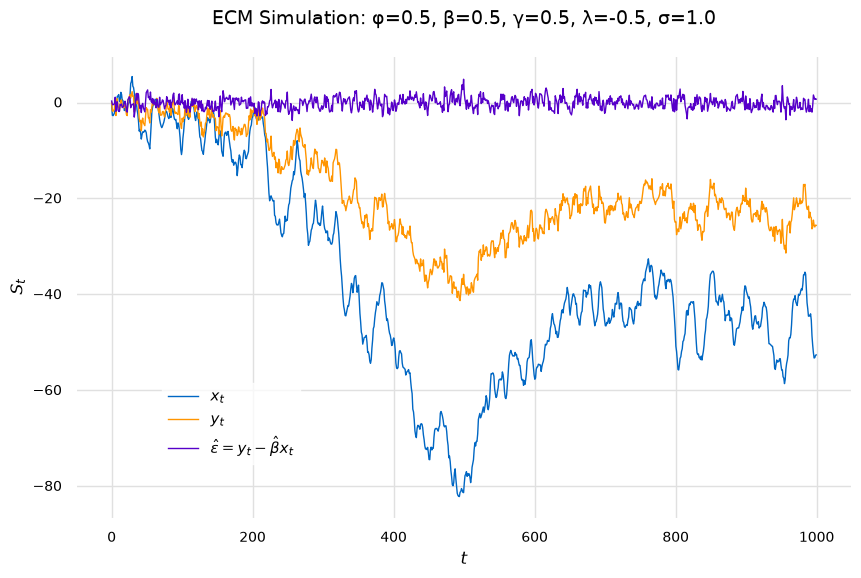

In [4]:
t, [xt, yt] = ecm.create_source(φ=φ, β=β, λ=λ, γ=γ, npts=npts)
ecm_comparison_plot(xt, yt, φ, β, γ, λ)

#### Residual Stationarity

In [5]:
εt = yt - β * xt
result, result_model = adf.compute_adf_test(εt)
result.summary()

╒════════════════╤═══════════════╕
│ Test Statistic │ -18.4575      │
├────────────────┼───────────────┤
│ pvalue         │   3.93551e-29 │
├────────────────┼───────────────┤
│ Lags           │   0           │
├────────────────┼───────────────┤
│ Number Obs     │ 999           │
╘════════════════╧═══════════════╛
╒════════════════╤══════════════════╤══════════╕
│ Significance   │   Critical Value │ Result   │
╞════════════════╪══════════════════╪══════════╡
│ 1%             │         -2.56798 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 5%             │         -1.94127 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 10%            │         -1.61656 │ Failed   │
╘════════════════╧══════════════════╧══════════╛


In [6]:
print(result_model.to_json(pretty=True))

{
    "status": "PASSED",
    "hyp_type": "LOWER_TAIL",
    "hyp_test_type": "STATIONARITY",
    "test_data": [
        {
            "status": "FAILED",
            "stat": {
                "test_id": "01ac022f-f5da-4b48-8fd4-b66a1a8b9e86",
                "label": "$t$",
                "value": -18.457537800811025
            },
            "pval": {
                "test_id": "01ac022f-f5da-4b48-8fd4-b66a1a8b9e86",
                "label": "$p-value$",
                "value": 3.935510857282335e-29
            },
            "params": [],
            "sig": {
                "test_id": "01ac022f-f5da-4b48-8fd4-b66a1a8b9e86",
                "label": "1%",
                "value": 0.01
            },
            "lower": {
                "test_id": "01ac022f-f5da-4b48-8fd4-b66a1a8b9e86",
                "label": "$t_L$",
                "value": -2.5679816723029334
            },
            "upper": null,
            "test_id": "01ac022f-f5da-4b48-8fd4-b66a1a8b9e86"
        },
  

In [7]:
result, beta_result_model = ecm.compute_beta_estimate(yt, xt)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.988
Model:                            OLS   Adj. R-squared:                  0.988
Method:                 Least Squares   F-statistic:                 8.065e+04
Date:                Sun, 30 Aug 2026   Prob (F-statistic):               0.00
Time:                        13:39:57   Log-Likelihood:                -1583.8
No. Observations:                1000   AIC:                             3172.
Df Residuals:                     998   BIC:                             3181.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.3969      0.075     -5.315      0.000      -0.543      -0.250
x1             0.4918      0.002    283.987      0.000       0.488       0.495
==============================================================================
Omnibus:                        1.628   Durbin-Watson:                   1.047
Prob(Omnibus):                  0.443   Jarque-Bera (JB):                1.704
Skew:                           0.087   Prob(JB):                        0.427
Kurtosis:                       2.897   Cond. No.                         86.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [8]:
print(beta_result_model.to_json(pretty=True))

{
   "est_model": "OLS",
   "const": {
      "est": -0.39694067778926456,
      "err": 0.07468387997423495,
      "est_label": "$\\beta$",
      "err_label": "$\\sigma_{\\beta}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "1ae0572c-2fbd-4e50-8ae8-11c3252e512c",
      "param_type": "OLS_CONST"
   },
   "params": [
      {
         "est": 0.4917594452014179,
         "err": 0.0017316243665862052,
         "est_label": "$\\alpha_1$",
         "err_label": "$\\sigma_{\\alpha_1}$",
         "row": 0,
         "column": 1,
         "order": 0,
         "est_id": "1ae0572c-2fbd-4e50-8ae8-11c3252e512c",
         "param_type": "OLS_PARAM"
      }
   ],
   "r2": {
      "est": 0.9877766220317078,
      "err": 0.0,
      "est_label": "$R^2$",
      "err_label": "$\\sigma_{R^2}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "1ae0572c-2fbd-4e50-8ae8-11c3252e512c",
      "param_type": "OLS_R2"
   },
   "param_transforms": [
      {
         "param"

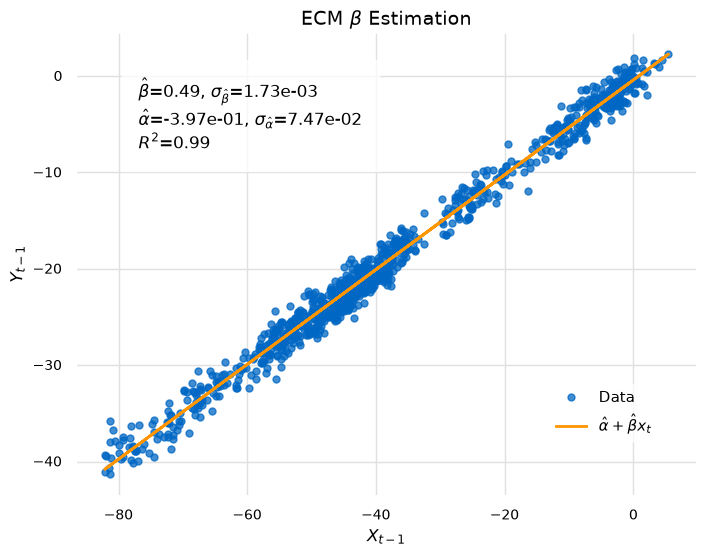

In [9]:
ecm_beta(yt, beta_result_model, xt)

### $\gamma$ and $\lambda$ Estimation

In [10]:
result, gamma_lambda_result_model = ecm.compute_gamma_lambda_estimate(yt, xt, beta_result_model.params[0].est)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.398
Model:                            OLS   Adj. R-squared:                  0.397
Method:                 Least Squares   F-statistic:                     328.9
Date:                Sun, 30 Aug 2026   Prob (F-statistic):          2.11e-110
Time:                        13:39:57   Log-Likelihood:                -1453.9
No. Observations:                 999   AIC:                             2914.
Df Residuals:                     996   BIC:                             2929.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.2079      0.035     -5.994      0.000      -0.276      -0.140
x1             0.4990      0.028     18.055      0.000       0.445       0.553
x2            -0.5238      0.028    -18.794      0.000      -0.579      -0.469
==============================================================================
Omnibus:                        0.635   Durbin-Watson:                   2.013
Prob(Omnibus):                  0.728   Jarque-Bera (JB):                0.689
Skew:                           0.058   Prob(JB):                        0.709
Kurtosis:                       2.945   Cond. No.                         1.50
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [11]:
print(gamma_lambda_result_model.to_json(pretty=True))

{
   "est_model": "OLS",
   "const": {
      "est": -0.20794592436967105,
      "err": 0.034694493827881936,
      "est_label": "$\\beta$",
      "err_label": "$\\sigma_{\\beta}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "00904cb4-cdab-4f03-b81b-add5c12e98b6",
      "param_type": "OLS_CONST"
   },
   "params": [
      {
         "est": 0.49895253822142427,
         "err": 0.027634875980664074,
         "est_label": "$\\alpha_1$",
         "err_label": "$\\sigma_{\\alpha_1}$",
         "row": 0,
         "column": 1,
         "order": 0,
         "est_id": "00904cb4-cdab-4f03-b81b-add5c12e98b6",
         "param_type": "OLS_PARAM"
      },
      {
         "est": -0.5238439286175856,
         "err": 0.027872689709444218,
         "est_label": "$\\alpha_2$",
         "err_label": "$\\sigma_{\\alpha_2}$",
         "row": 0,
         "column": 2,
         "order": 0,
         "est_id": "00904cb4-cdab-4f03-b81b-add5c12e98b6",
         "param_type": "OLS_PARAM"
  